In [ ]:
import os
import sys
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from collections import Counter

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Project Root
# NOTE: __file__ is only defined when running as a script (python script.py).
# In notebooks / interactive cells (Jupyter, VS Code interactive window) it
# doesn't exist, so we fall back to the current working directory instead.
# __file__ points at a FILE, so BASE_DIR = dirname(__file__).
# cwd already IS a directory, so in the fallback case BASE_DIR = cwd directly
# (no extra dirname(), or you'd climb one level too high).
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.path.abspath(os.getcwd())

PROJECT_ROOT = os.path.dirname(BASE_DIR)

sys.path.insert(0, PROJECT_ROOT)

from evaluation import evaluate_model

# ============================================================
# Configuration
# ============================================================


dataset_path = os.path.join(
    BASE_DIR,
    "..",
    "DATASETS",
    "Rice_Leaf_AUG"
)

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 25

LEARNING_RATE = 1e-5

MODEL_NAME = "MobileNetV2"

MODEL_FILE = "rice_mobilenetv2.keras"

# ============================================================
# Data Preprocessing
# ============================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,

    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# ============================================================
# Load Dataset
# ============================================================

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# ============================================================
# Dataset Information
# ============================================================

num_classes = train_data.num_classes

print(f"\nDetected Classes: {num_classes}")
print(train_data.class_indices)

with open("class_indices.pkl", "wb") as f:
    pickle.dump(train_data.class_indices, f)

print("\nClass Distribution:")
print(Counter(train_data.classes))

# ============================================================
# Load Pretrained MobileNetV2
# ============================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Fine tuning MobileNetV2

base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# ============================================================
# Build Model
# ============================================================

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation="softmax"
    )
])

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

with open("model_summary.txt", "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved.")

# ============================================================
# Callbacks
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_FILE,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# ============================================================
# Train Model
# ============================================================

print("\nStarting Training...\n")

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

# ============================================================
# Save Training History
# ============================================================

with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")

# ============================================================
# Evaluate Model
# ============================================================

model = load_model(MODEL_FILE)

loss, accuracy = model.evaluate(val_data)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

evaluate_model(
    model=model,
    history=history,
    val_data=val_data,
    model_name=MODEL_NAME,
    training_time=training_time,
    model_path=MODEL_FILE
)

print("Evaluation completed.")

Found 3066 images belonging to 6 classes.
Found 763 images belonging to 6 classes.

Detected Classes: 6
{'Bacterial Leaf Blight': 0, 'Brown Spot': 1, 'Healthy Rice Leaf': 2, 'Leaf Blast': 3, 'Leaf scald': 4, 'Sheath Blight': 5}

Class Distribution:
Counter({np.int32(2): 523, np.int32(1): 517, np.int32(0): 509, np.int32(3): 508, np.int32(5): 506, np.int32(4): 503})


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 1,855,878 (7.08 MB)

 Non-trainable params: 731,584 (2.79 MB)

Model summary saved.

Starting Training...

Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.1936 - loss: 2.0768
Epoch 1: val_accuracy improved from None to 0.30931, saving model to rice_mobilenetv2.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 919ms/step - accuracy: 0.2149 - loss: 1.9511 - val_accuracy: 0.3093 - val_loss: 1.7138
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.3080 - loss: 1.7262
Epoch 2: val_accuracy improved from 0.30931 to 0.36042, saving model to rice_mobilenetv2.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 777ms/step - accuracy: 0.3483 - loss: 1.6496 - val_accuracy: 0.3604 - val_loss: 1.5394
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.4403 - loss: 1.4494
Epoch 3: val_accuracy improved from 0.36042 to 0.42464, saving model to rice_mobilenetv2.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 756ms/step - accuracy: 0.4586 - loss: 1.4162 - val_accuracy: 0.4246 - val_loss: 1.4216
Epoch 4/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy

Test Image name:  brownspot.jpg


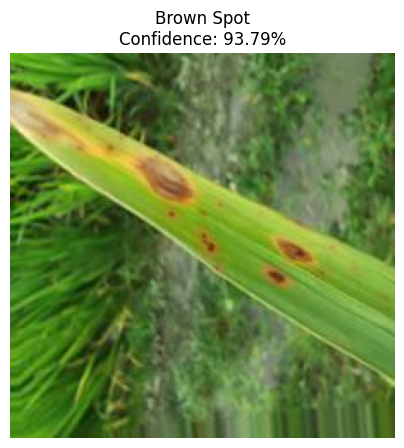

Prediction
Predicted Class : Brown Spot
Confidence      : 93.79%

Class Probabilities

Bacterial Leaf Blight     : 0.79%
Brown Spot                : 93.79%
Healthy Rice Leaf         : 0.01%
Leaf Blast                : 4.91%
Leaf scald                : 0.45%
Sheath Blight             : 0.04%


In [1]:
#PREDICTION




import pickle

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ============================================================
# CONFIGURATION
# ============================================================

# Matches MODEL_FILE from the training script (saved in the same
# directory the training script was run from, not a subfolder).
MODEL_PATH = "rice_mobilenetv2.keras"

# Matches the pickle the training script saves via
# `pickle.dump(train_data.class_indices, f)`
CLASS_INDICES_PATH = "class_indices.pkl"

IMAGE_PATH = r"brownspot.jpg"     # <-- change this

IMG_SIZE = 224

# ============================================================
# LOAD MODEL
# ============================================================

model = load_model(MODEL_PATH)

# ============================================================
# LOAD CLASS NAMES
# ============================================================
# class_indices.pkl looks like {"Bacterial Leaf Blight": 0, "Brown Spot": 1, ...}
# We invert it to get {0: "Bacterial Leaf Blight", 1: "Brown Spot", ...}
# so CLASS_NAMES[i] always lines up with the model's output index i,
# regardless of what order flow_from_directory happened to alphabetize them in.

with open(CLASS_INDICES_PATH, "rb") as f:
    class_indices = pickle.load(f)

CLASS_NAMES = [
    cls for cls, idx in sorted(class_indices.items(), key=lambda item: item[1])
]

# ============================================================
# LOAD IMAGE
# ============================================================

image = tf.keras.preprocessing.image.load_img(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE)
)

image_array = tf.keras.preprocessing.image.img_to_array(image)

display_image = image_array.astype(np.uint8)

# IMPORTANT: the training pipeline applies MobileNetV2's preprocess_input
# via the ImageDataGenerator's `preprocessing_function`, OUTSIDE the model.
# The saved model has no preprocessing layer of its own, so we must apply
# the exact same preprocessing here, or predictions will not match training.
image_array = preprocess_input(image_array)

image_array = np.expand_dims(image_array, axis=0)

# ============================================================
# PREDICTION
# ============================================================

predictions = model.predict(image_array, verbose=0)

predicted_index = np.argmax(predictions)

predicted_class = CLASS_NAMES[predicted_index]

confidence = predictions[0][predicted_index] * 100


print("Test Image name: ", IMAGE_PATH)

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.axis("off")
plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("=" * 60)
print("Prediction")
print("=" * 60)

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

print("\nClass Probabilities\n")

for cls, prob in zip(CLASS_NAMES, predictions[0]):
    print(f"{cls:<25} : {prob*100:.2f}%")